# Posterior for K. pneumoniae local recombination rate and mutation rate using SBI

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from Bio import Phylo
import seaborn as sns
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform
from LeaveLengthOut_NN import LeaveLengthOut_NN

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load K. pneumoniae gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/klebsiella/klebsiella_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

         ___________________________ 6K89HyFBbDwXdwchwqkADP-GCA_019928025
       _|
      | |    _______________________ o3RhFr5btpW7DTfXtue7c5-GCA_019927485
      | |___|
      |     |_______________________ spc6uUrrN2v9jc6UX7DiRy-GCA_019930485
     ,|
     ||       ______________________ w7tJjbUBPZePmFG3NDmzp5-GCA_019928665
     ||  ____|
     || |    |______________________ xaAjEgiWJ6VpYxwkH9LSk9-GCA_019928595
     ||_|
     |  |     ______________________ nSFymoP4AQEsMnKgY82Syr-GCA_019928285
     |  |____|
     |       |______________________ 1k2mmojDYi7HwWwByEje5E-GCA_019928115
     |
     |        ______________________ 5rzNEErwwW9sBnVoSPeLxJ-GCA_019927845
     |   ____|
     |  |    |______________________ 7iUximMjZSb8j3oo5o3GyN-GCA_019927325
  ___|  |
 |   | _|     ______________________ 19UUUUQvAAyHsrWsprUbF7-GCA_019927745
 |   || |____|
 |   || |    |______________________ pVybzfzKoAGacFHHpXyyko-GCA_019928045
 |   || |
 |   || |     ______________________ bKMwQNtdgmF9bNgpmS6F

In [3]:
drop_col = range(16, 32)

In [4]:
x_obs_8000_df1 = pd.read_csv("../data/klebsiella/summary_stats/rand_seg8000_i.csv", header=None)
x_obs_8000_df2 = pd.read_csv("../data/klebsiella/summary_stats/rand_seg8000_ii.csv", header=None)
x_obs_np = np.concatenate((x_obs_8000_df1.to_numpy(), x_obs_8000_df2.to_numpy()), axis=0)
x_obs_np = np.delete(x_obs_np, drop_col, axis=1)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([2000, 30]), torch.float32)

In [5]:
x_obs_rand_df = pd.read_csv("../data/klebsiella/summary_stats/rand_seg_2.csv", header=None)
x_obs_np2 = x_obs_rand_df.to_numpy()
x_obs_np2 = np.delete(x_obs_np2, drop_col, axis=1)
x_obs_torch2 = torch.tensor(x_obs_np2, device=torch_device)
x_obs_torch2 = x_obs_torch2.to(torch.float32)
x_obs_torch2.shape, x_obs_torch2.dtype

(torch.Size([2000, 30]), torch.float32)

### Delete observations with no signal

In [6]:
no_signal_id = np.where(x_obs_np[:, 17] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((0,), array([], dtype=int64))

In [7]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((2000, 30), torch.Size([2000, 30]), torch.float32)

In [8]:
no_signal_id2 = np.where(x_obs_np2[:, 17] == 0)[0]
no_signal_id2.shape, no_signal_id2[:10]

((6,), array([ 934, 1329, 1478, 1686, 1726, 1864]))

In [9]:
x_obs_np2 = np.delete(x_obs_np2, no_signal_id2, axis=0)
x_obs_torch2 = torch.tensor(x_obs_np2, device=torch_device)
x_obs_torch2 = x_obs_torch2.to(torch.float32)
x_obs_np2.shape, x_obs_torch2.shape, x_obs_torch2.dtype

((1994, 30), torch.Size([1994, 30]), torch.float32)

## Load simulation data

In [10]:
theta1 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x1.csv', delimiter=",")
nrow1 = x1.shape[0]

theta2 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x2.csv', delimiter=",")
nrow2 = x2.shape[0]

theta3 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x3.csv', delimiter=",")
nrow3 = x3.shape[0]

theta4 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x4.csv', delimiter=",")
nrow4 = x4.shape[0]

theta5 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x5.csv', delimiter=",")
nrow5 = x5.shape[0]

theta6 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta6.csv', delimiter=",")
x6 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x6.csv', delimiter=",")
nrow6 = x6.shape[0]

theta7 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta7.csv', delimiter=",")
x7 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x7.csv', delimiter=",")
nrow7 = x7.shape[0]

theta8 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta8.csv', delimiter=",")
x8 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x8.csv', delimiter=",")
nrow8 = x8.shape[0]

theta9 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta9.csv', delimiter=",")
x9 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x9.csv', delimiter=",")
nrow9 = x9.shape[0]

theta10 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta10.csv', delimiter=",")
x10 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x10.csv', delimiter=",")
nrow10 = x10.shape[0]

x = np.vstack([x1, x2, x3, x4, x5, x6, x7, x8, x9, x10])
x = np.delete(x, drop_col, axis=1)
theta = np.vstack([theta1[:nrow1], theta2[:nrow2], theta3[:nrow3], theta4[:nrow4], theta5[:nrow5],
                   theta6[:nrow6], theta7[:nrow7], theta8[:nrow8], theta9[:nrow9], theta10[:nrow10]])

print(theta.shape, x.shape)

(34800, 3) (34800, 30)


In [11]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [18]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch2.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(30):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch2[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 17 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch2[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 2 is outside the range of simulated data.
Observation 4 is outside the range of simulated data.
Observation 5 is outside the range of simulated data.
Observation 6 is outside the range of simulated data.
Observation 7 is outside the range of simulated data.
Observation 8 is outside the range of simulated data.
Observation 9 is outside the range of simulated data.
Observation 10 is outside the range of simulated data.
Observation 12 is outside the range of simulated data.
Observation 13 is outside the range of simulated data.
Observation 14 is outside the range of simulated data.
Observation 15 is outside the range of simulated data.
Observation 16 is outside the range of simulated data.
Observation 17 is outside the range of simulated data.
Observation 18 is outside the range of simulated data.
Observation 20 is outside the range of simulated data.
Observation 21 is outside the range of simulated data.
Observation 22 is outside the range of simulated data.
Observation 23 is

In [19]:
len(ignore_indices), len(no_segregation), len(out_stats)

(1403, 0, 1403)

In [20]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [21]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [22]:
for i in range(30):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 526
Index 1: 346
Index 2: 118
Index 3: 92
Index 4: 595
Index 5: 364
Index 6: 113
Index 7: 135
Index 8: 712
Index 9: 311
Index 10: 0
Index 11: 0
Index 12: 525
Index 13: 237
Index 14: 12
Index 15: 61
Index 16: 257
Index 17: 404
Index 18: 118
Index 19: 270
Index 20: 1027
Index 21: 0
Index 22: 1386
Index 23: 1285
Index 24: 0
Index 25: 447
Index 26: 4
Index 27: 0
Index 28: 4
Index 29: 0


## NPE

### Create prior to pass range knowledge to NPE

In [12]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.05]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.02]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [13]:
embedding_net = LeaveLengthOut_NN(
    input_dim=30,
    num_hiddens=128,
    num_hidden_layers=1,
    num_outputs=2)
neural_posterior = posterior_nn(
    model="nsf",
    embedding_net=embedding_net,
    hidden_features=30,
    num_transforms=8,
    num_bins=5,
    z_score_theta="independent",
    z_score_x="independent"
)

In [14]:
seed = 100
num_posterior_samples=1000

inference = NPE_C(density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [15]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500,
    training_batch_size=100,
    learning_rate=0.0001,
    stop_after_epochs=20,
    clip_max_norm=None
)
posterior = inference.build_posterior(density_estimator)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [10, 11, 12, 13, 20, 22, 23, 25, 26, 27, 28] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 202 epochs.

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\potentials\posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


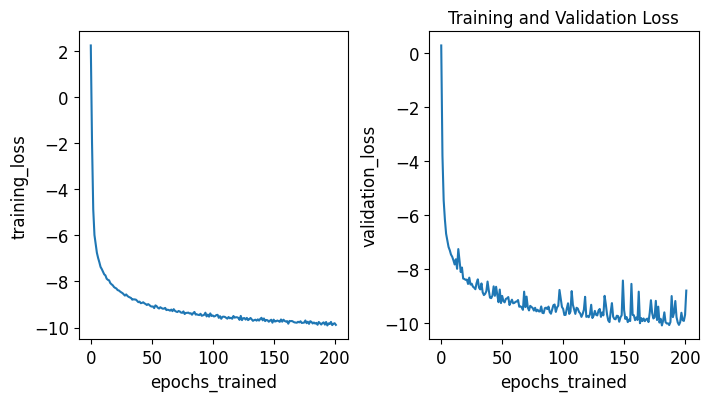

In [16]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Save the trained NPE

In [17]:
save_path = "../data/klebsiella/trained_npe_density_estimator_drop.pt"

torch.save(
    {
        "density_estimator": density_estimator,
        "prior": prior,
        "sbi_version": sbi.__version__,
        "learning_rate": 0.0001,
        "max_num_epochs": 500,
    },
    save_path,
)

### Plug in observations from real genes to get posterior

In [23]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(2000, 1000, 3)

In [24]:
theta_post2 = np.full((x_obs_torch2.shape[0], num_posterior_samples, 3), np.nan)
theta_post2.shape

(1994, 1000, 3)

In [25]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


In [26]:
for i in range(x_obs_torch2.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch2 = posterior.sample((num_posterior_samples,), x=x_obs_torch2[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post2[i, :, :] = theta_post_torch2.cpu().detach().numpy()

### Plot bar plots by position

In [80]:
gene_info = pd.read_csv("../data/klebsiella/rand_seg_info.csv")
gene_info_np = gene_info.to_numpy()[4000:, :]
gene_info_np

array([[8000, 2698572, 2706571, True],
       [8000, 3157703, 3165702, True],
       [8000, 4942213, 4950212, True],
       ...,
       [8000, 1276697, 1284696, True],
       [8000, 1012248, 1020247, True],
       [8000, 1132102, 1140101, True]], shape=(2000, 4), dtype=object)

In [81]:
gene_info2 = pd.read_csv("../data/klebsiella/rand_seg_info2.csv")
gene_info_np2 = gene_info2.to_numpy()
gene_info_np2

array([[7036, 1873417, 1880452, True],
       [8139, 4405060, 4413198, True],
       [179, 2961240, 2961418, True],
       ...,
       [3189, 4487022, 4490210, True],
       [9582, 3536536, 3546117, True],
       [1801, 1866471, 1868271, True]], shape=(2000, 4), dtype=object)

In [82]:
plot_xlim = [0.0, 5280085.0]
samples_x = gene_info_np[:, 1]
samples_x.shape

(2000,)

In [83]:
posterior_median = np.median(theta_post[:, :, 0], axis=1)
posterior_median.shape

(2000,)

In [84]:
ci_lower_bounds = np.percentile(theta_post[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((2000,), (2000,))

In [85]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [86]:
median_rho = np.median(posterior_median)
median_rho

np.float64(-0.010332527803257108)

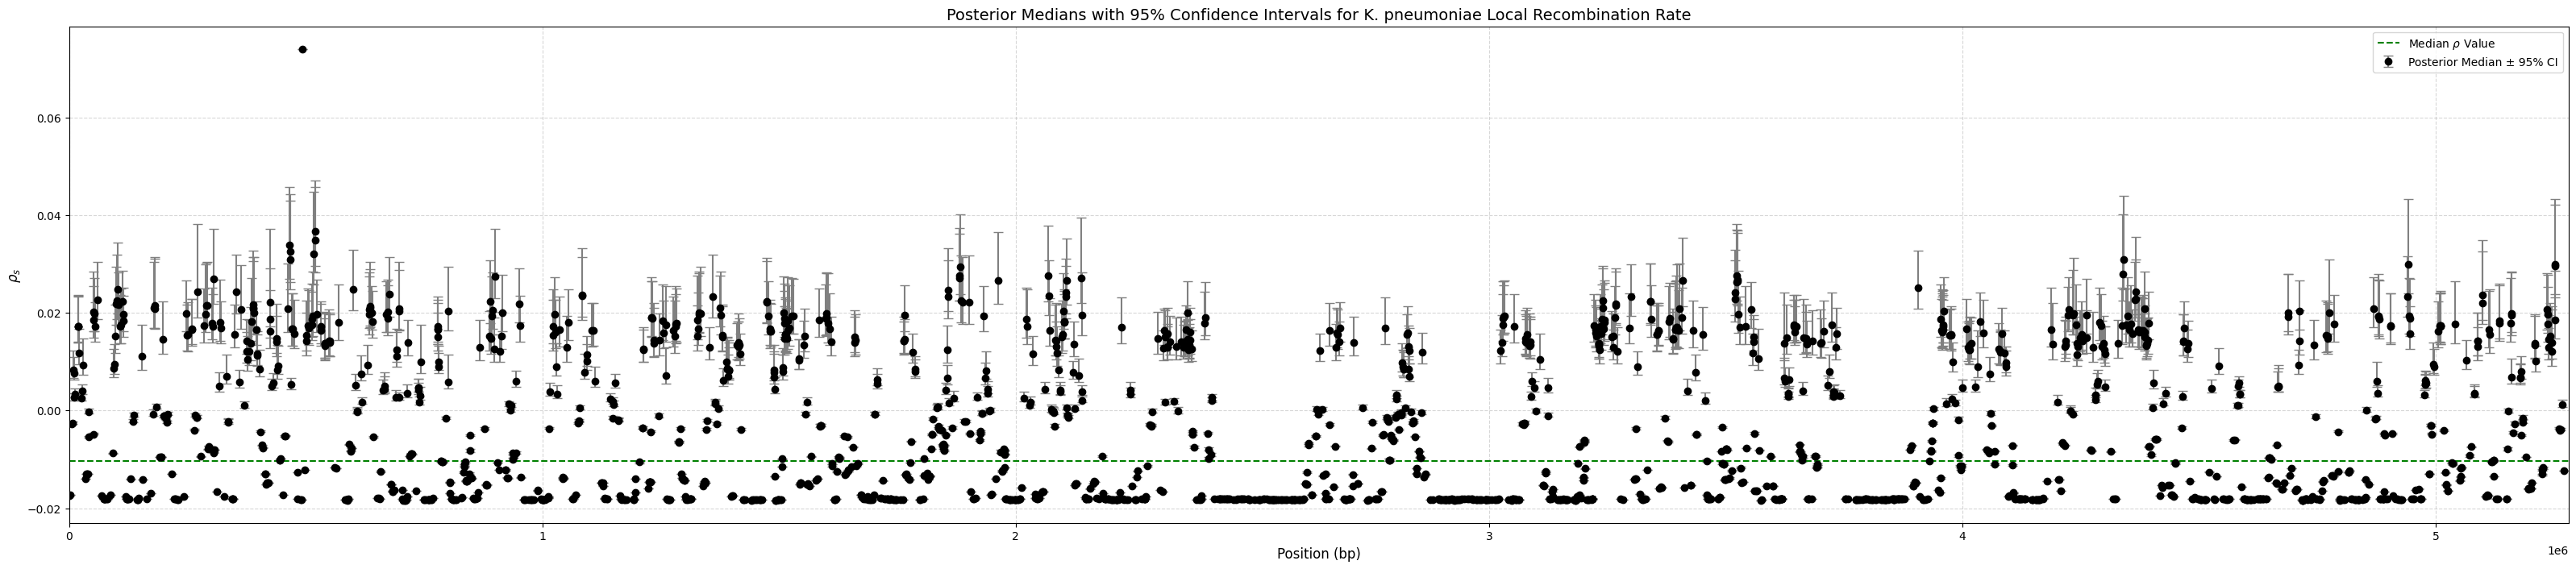

In [87]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for K. pneumoniae Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=median_rho, color='green', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [88]:
posterior_median_theta = np.median(theta_post[:, :, 1], axis=1)
posterior_median_theta.shape

(2000,)

In [89]:
ci_lower_bounds_theta = np.percentile(theta_post[:, :, 1], 2.5, axis=1)
ci_upper_bounds_theta = np.percentile(theta_post[:, :, 1], 97.5, axis=1)
ci_lower_bounds_theta.shape, ci_upper_bounds_theta.shape

((2000,), (2000,))

In [90]:
lower_errors_theta = posterior_median_theta - ci_lower_bounds_theta
upper_errors_theta = ci_upper_bounds_theta - posterior_median_theta
yerr_theta = [lower_errors_theta, upper_errors_theta]

In [91]:
median_theta = np.median(posterior_median_theta)
median_theta

np.float64(-0.0033726055989973247)

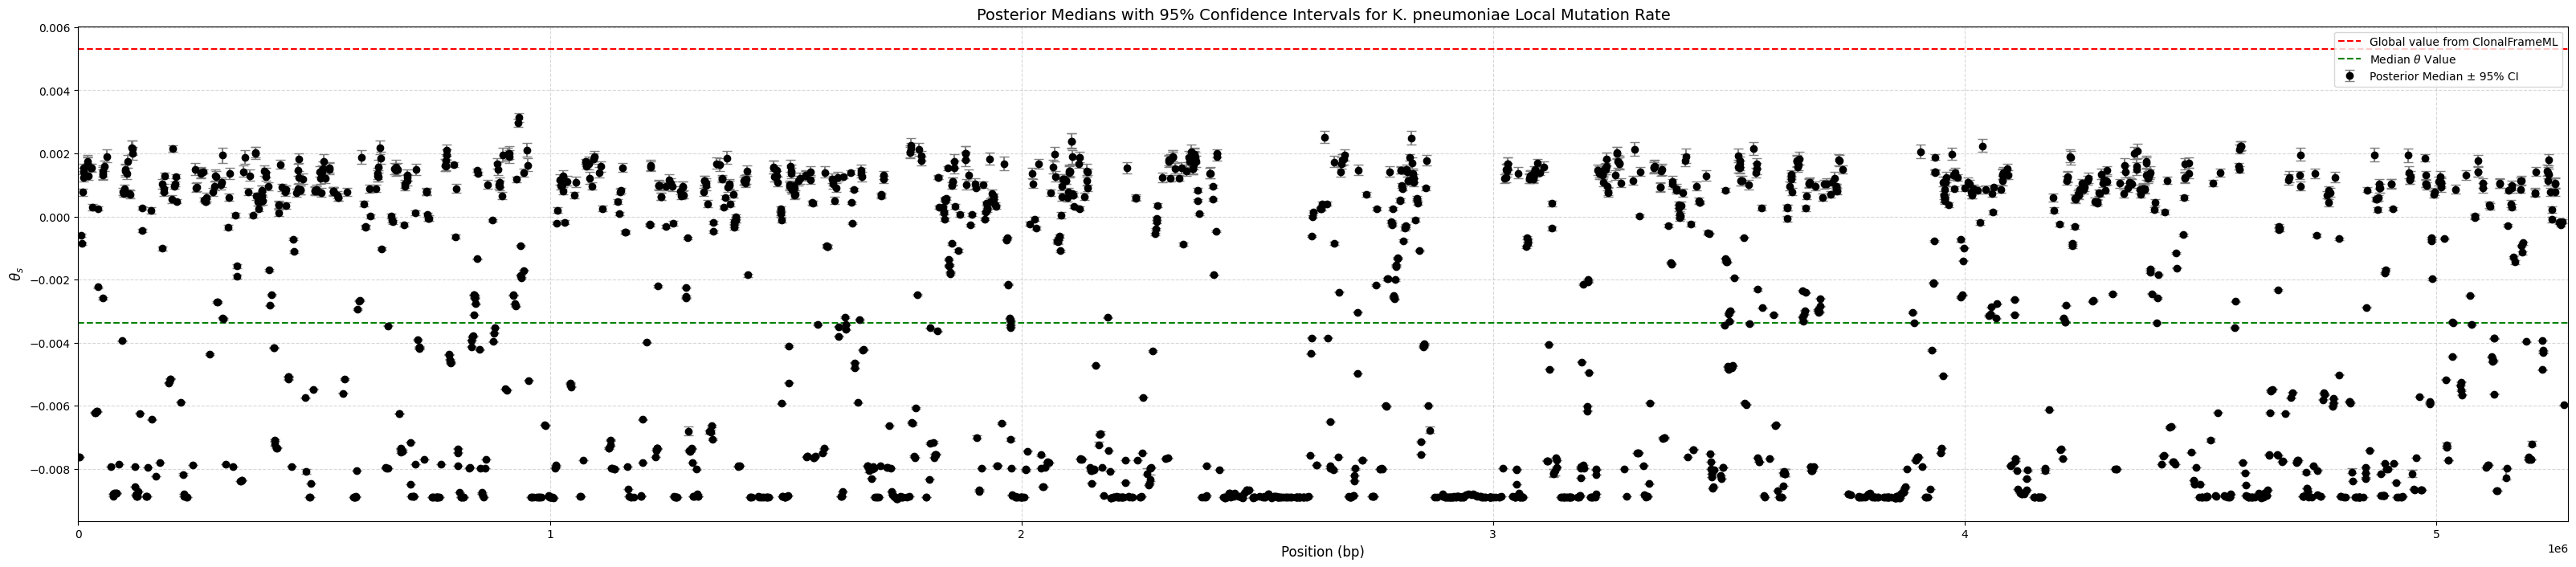

In [92]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median_theta, yerr=yerr_theta, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for K. pneumoniae Local Mutation Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\theta_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.005315038780002285, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_theta, color='green', linestyle='dashed', label=r'Median $\theta$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [93]:
samples_l = np.delete(gene_info_np[:, 0], no_signal_id)
samples_l.shape

(2000,)

In [94]:
posterior_l_median = np.median(theta_post[:, :, 2], axis=1)
posterior_l_median.shape

(2000,)

In [95]:
ci_lower_bounds_l = np.percentile(theta_post[:, :, 2], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post[:, :, 2], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((2000,), (2000,))

In [96]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

In [97]:
samples_l

array([8000, 8000, 8000, ..., 8000, 8000, 8000],
      shape=(2000,), dtype=object)

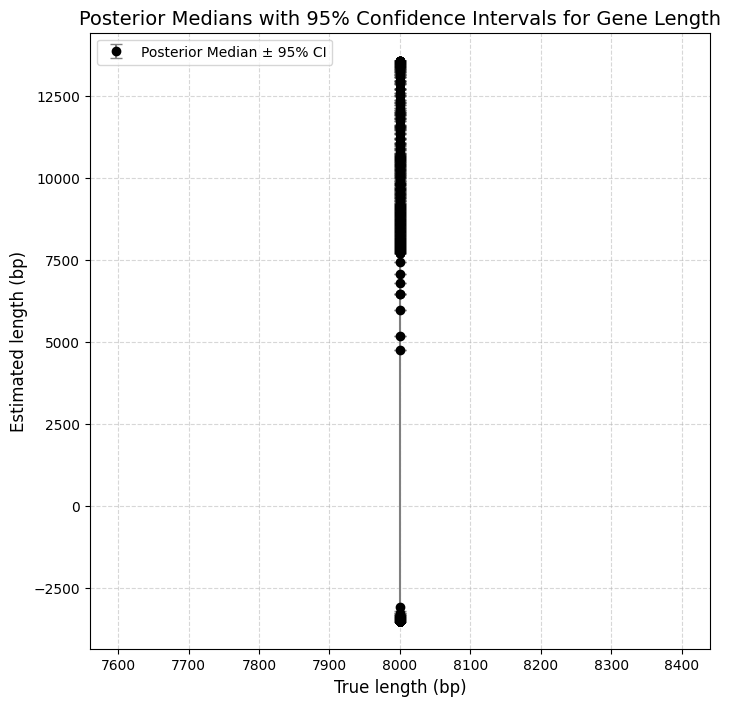

In [98]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

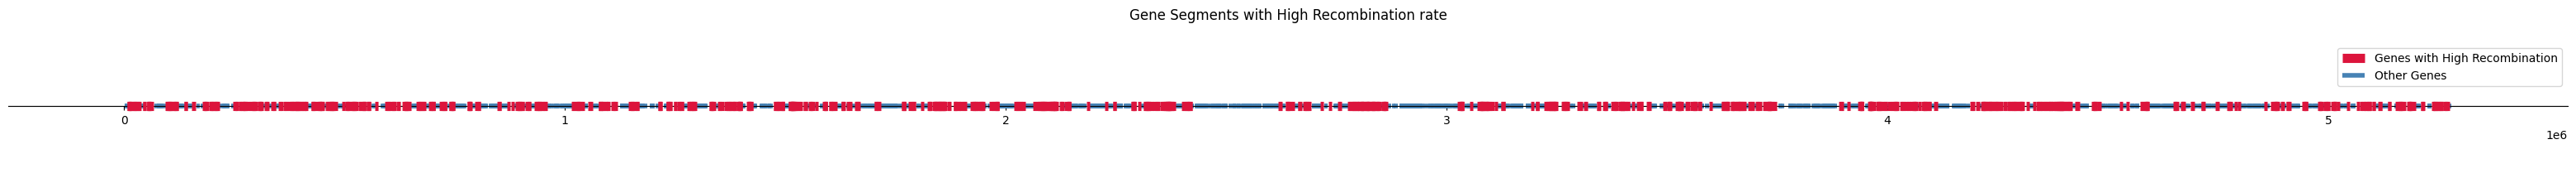

In [99]:
y_level = 0
gene_starts = np.delete(gene_info_np[:, 1], no_signal_id)
gene_ends   = np.delete(gene_info_np[:, 2], no_signal_id)

# high_recomb_index = np.where(ci_lower_bounds >= 0.0003887292720131564)[0]
high_recomb_index = np.where(ci_lower_bounds >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

# other_genes_index = np.where(ci_lower_bounds < 0.0003887292720131564)[0]
other_genes_index = np.where(ci_lower_bounds < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()

In [100]:
plot_xlim = [0.0, 5280085.0]
samples_x = np.delete(gene_info_np2[:, 1], no_signal_id2)
samples_x.shape

(1994,)

In [101]:
posterior_median = np.median(theta_post2[:, :, 0], axis=1)
posterior_median.shape

(1994,)

In [102]:
ci_lower_bounds = np.percentile(theta_post2[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post2[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((1994,), (1994,))

In [103]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [104]:
median_rho = np.median(posterior_median)
median_rho

np.float64(-0.0015454832755494863)

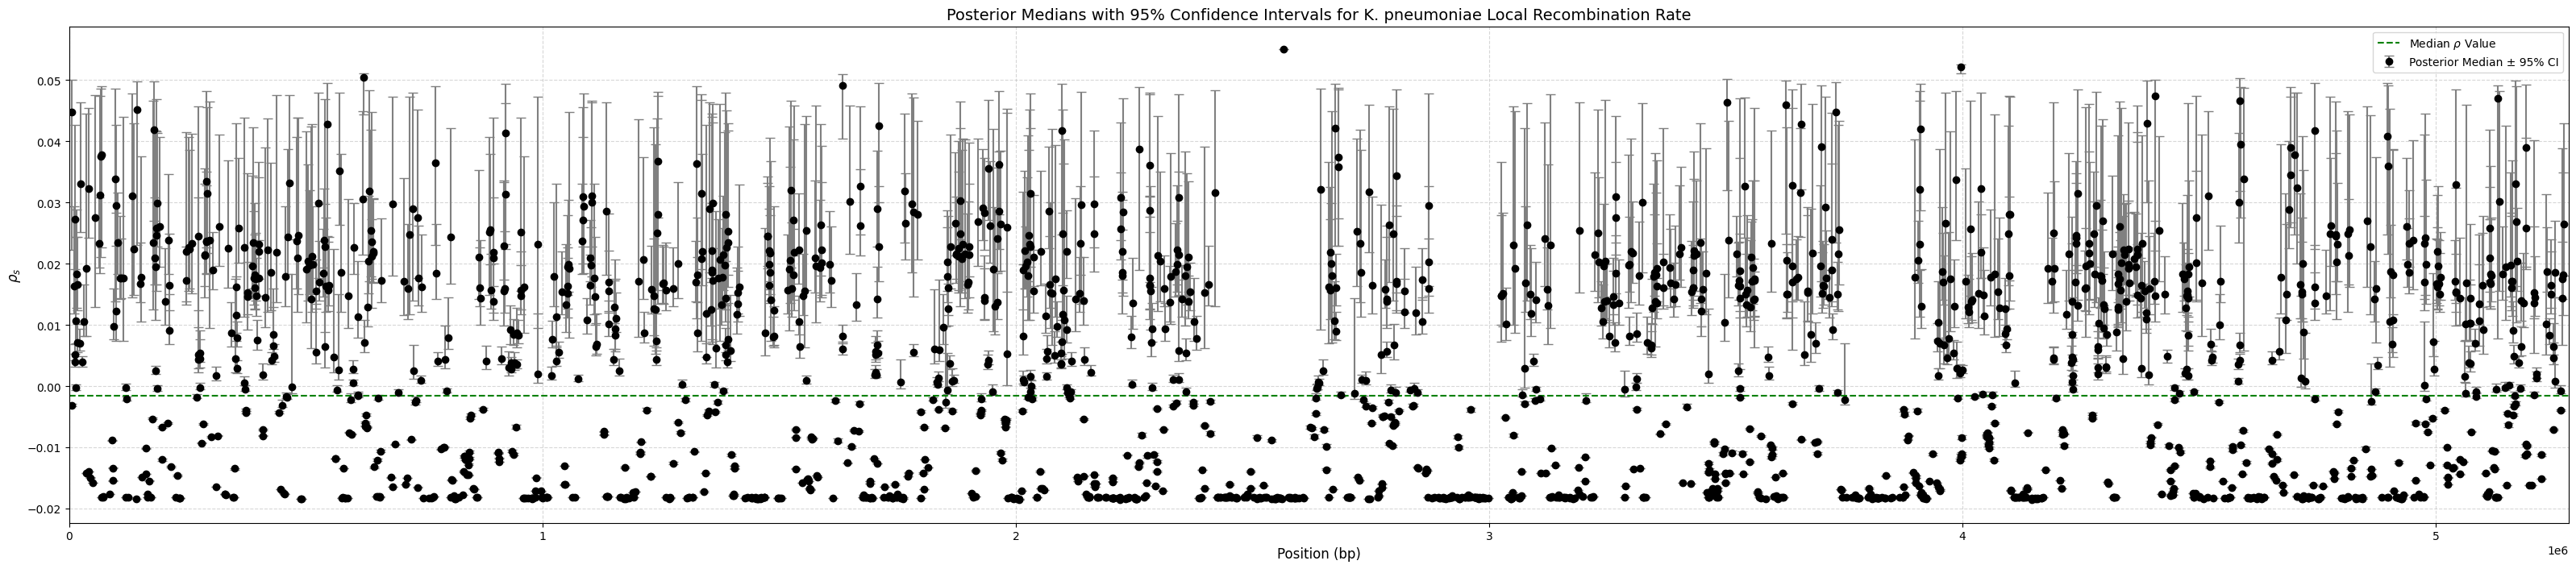

In [105]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for K. pneumoniae Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=median_rho, color='green', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [111]:
posterior_median_theta = np.median(theta_post2[:, :, 1], axis=1)
posterior_median_theta.shape

(1994,)

In [112]:
ci_lower_bounds_theta = np.percentile(theta_post2[:, :, 1], 2.5, axis=1)
ci_upper_bounds_theta = np.percentile(theta_post2[:, :, 1], 97.5, axis=1)
ci_lower_bounds_theta.shape, ci_upper_bounds_theta.shape

((1994,), (1994,))

In [113]:
lower_errors_theta = posterior_median_theta - ci_lower_bounds_theta
upper_errors_theta = ci_upper_bounds_theta - posterior_median_theta
yerr_theta = [lower_errors_theta, upper_errors_theta]

In [114]:
median_theta = np.median(posterior_median_theta)
median_theta

np.float64(0.00027633482386590913)

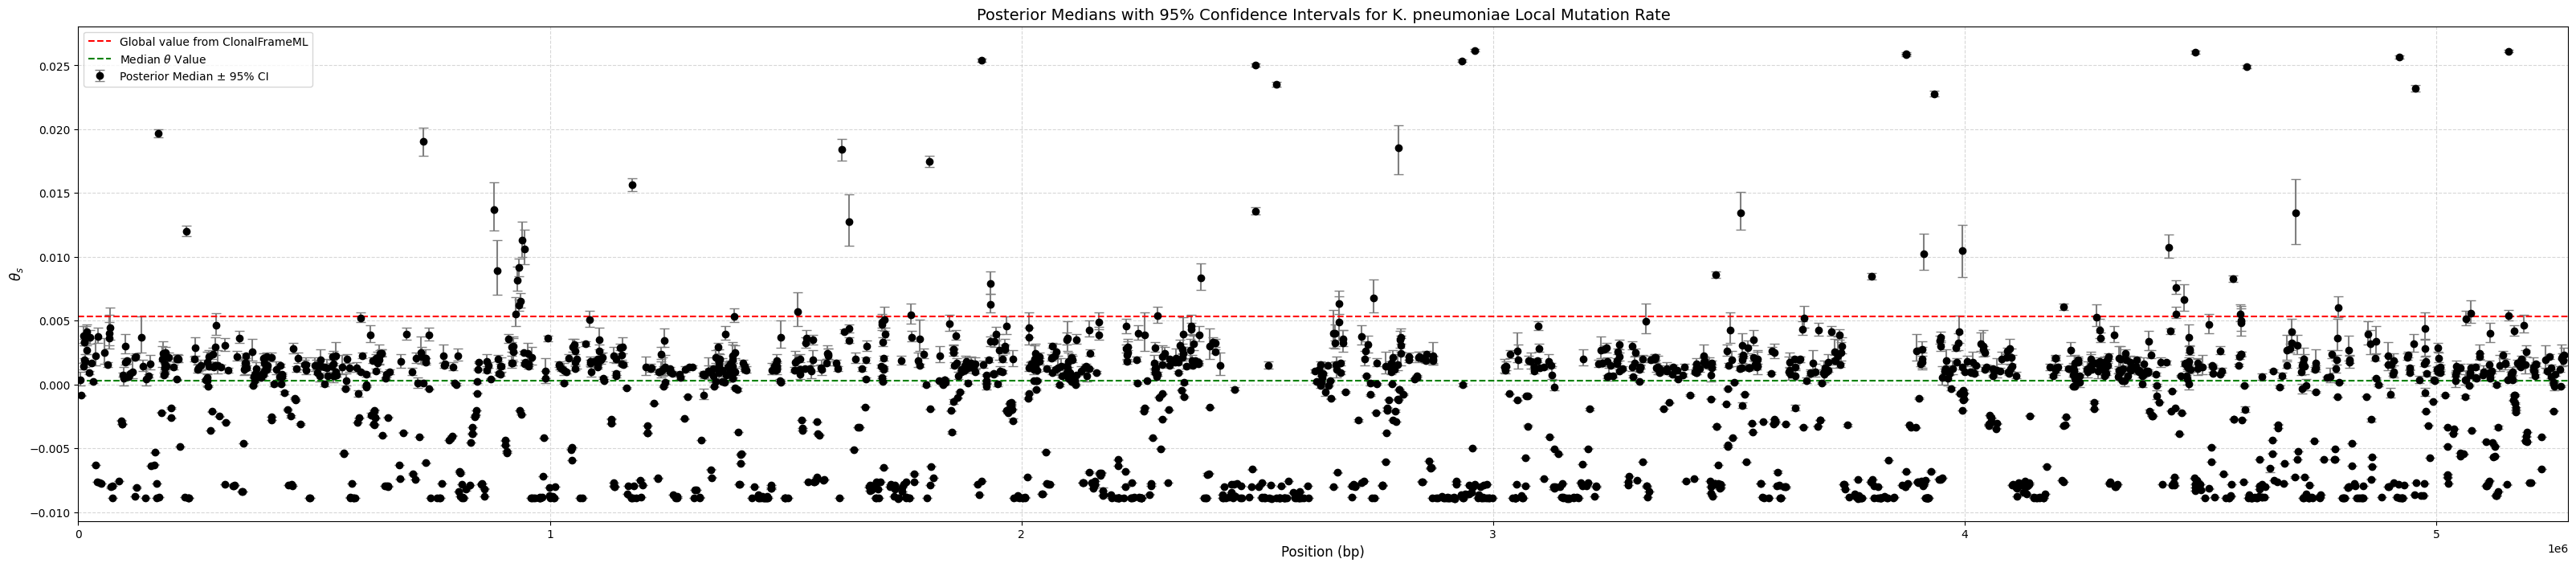

In [115]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median_theta, yerr=yerr_theta, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for K. pneumoniae Local Mutation Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\theta_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.005315038780002285, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_theta, color='green', linestyle='dashed', label=r'Median $\theta$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [118]:
samples_l = np.delete(gene_info_np2[:, 0], no_signal_id2)
samples_l.shape

(1994,)

In [119]:
posterior_l_median = np.median(theta_post2[:, :, 2], axis=1)
posterior_l_median.shape

(1994,)

In [120]:
ci_lower_bounds_l = np.percentile(theta_post2[:, :, 2], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post2[:, :, 2], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((1994,), (1994,))

In [121]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

In [122]:
samples_l

array([7036, 8139, 179, ..., 3189, 9582, 1801],
      shape=(1994,), dtype=object)

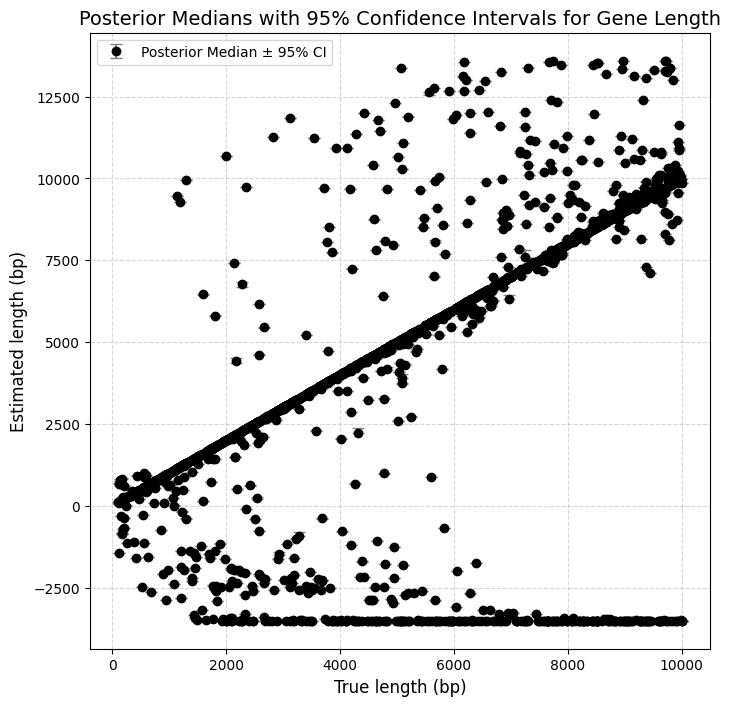

In [123]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()